Load libraries & set parameters

In [2]:
import duckdb
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Paths
DATA_DIR = "./"
BLOCKS = DATA_DIR + "blocks.parquet"
POSTS  = DATA_DIR + "posts.parquet"
FOLLOWS = DATA_DIR + "follows.parquet"

# Time window
START_DATE = "2024-08-15"
END_DATE   = "2024-09-15"

# Filtering thresholds 
MIN_BLOCKS_GIVEN = 10
MIN_POSTS = 5
MIN_FOLLOWS = 5

con = duckdb.connect(database=":memory:")

Select the final user set

In [3]:
active_users_query = f"""
WITH blocks_users AS (
    SELECT did_id
    FROM read_parquet('{BLOCKS}')
    WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY did_id
    HAVING COUNT(*) >= {MIN_BLOCKS_GIVEN}
),
post_users AS (
    SELECT did_id
    FROM read_parquet('{POSTS}')
    WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY did_id
    HAVING COUNT(*) >= {MIN_POSTS}
),
follow_users AS (
    SELECT did_id
    FROM read_parquet('{FOLLOWS}')
    WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY did_id
    HAVING COUNT(*) >= {MIN_FOLLOWS}
)

SELECT b.did_id
FROM blocks_users b
JOIN post_users  p ON b.did_id = p.did_id
JOIN follow_users f ON b.did_id = f.did_id
"""

users_df = con.execute(active_users_query).fetchdf()
print("Final users:", len(users_df))
users_df.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Final users: 36874


,did_id
0,86197
1,620908
2,618690
3,1015582
4,1222294


Build the block graph

In [4]:
blocks_edges = con.execute(f"""
SELECT
    did_id AS src,
    subject_did_id AS dst
FROM read_parquet('{BLOCKS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
AND did_id IN (SELECT did_id FROM users_df)
AND subject_did_id IN (SELECT did_id FROM users_df)
""").fetchdf()

print("Block edges:", len(blocks_edges))

Block edges: 190852


Create the NetworkX graph

In [5]:
G = nx.DiGraph()
G.add_edges_from(blocks_edges[['src', 'dst']].itertuples(index=False))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Nodes: 32111
Edges: 190849


Saving the graph to use it in other tasks

In [6]:
nx.write_graphml(G, "blocks_graph.graphml")

Compute graph-based node features

In [9]:
node_features = pd.DataFrame(index=G.nodes())

# Degree-based
node_features["out_degree"] = pd.Series(dict(G.out_degree()))
node_features["in_degree"]  = pd.Series(dict(G.in_degree()))

# Ratios
node_features["block_ratio"] = (
    node_features["out_degree"] /
    (node_features["in_degree"] + 1)
)

# Centrality 
node_features["pagerank"] = pd.Series(nx.pagerank(G, alpha=0.85))

# Reciprocity 
node_features["reciprocity"] = [
    nx.reciprocity(G, node) if node in G else 0
    for node in node_features.index
]

print(node_features.head())


          out_degree  in_degree  block_ratio  pagerank  reciprocity
109144            12          1     6.000000  0.000023      0.00000
29745745          18         75     0.236842  0.000141      0.00000
17362021           5        528     0.009452  0.001106      0.00000
5096582            6        730     0.008208  0.001396      0.00000
21733425          10        857     0.011655  0.001921      0.00692


Add activity features for each node

In [10]:
posts_feat = con.execute(f"""
SELECT did_id, COUNT(*) AS posts_count
FROM read_parquet('{POSTS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
GROUP BY did_id
""").fetchdf()

node_features = node_features.merge(
    posts_feat, left_index=True, right_on="did_id", how="left"
).set_index("did_id")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [11]:
following_feat = con.execute(f"""
SELECT did_id, COUNT(*) AS following
FROM read_parquet('{FOLLOWS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
GROUP BY did_id
""").fetchdf()

node_features = node_features.merge(
    following_feat, left_index=True, right_on="did_id", how="left"
).set_index("did_id")


In [12]:
followers_feat = con.execute(f"""
SELECT subject_did_id AS did_id, COUNT(*) AS followers
FROM read_parquet('{FOLLOWS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
GROUP BY subject_did_id
""").fetchdf()

node_features = node_features.merge(
    followers_feat, left_index=True, right_on="did_id", how="left"
).set_index("did_id")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [13]:
blocks_given_feat = con.execute(f"""
SELECT did_id, COUNT(*) AS blocks_given
FROM read_parquet('{BLOCKS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
GROUP BY did_id
""").fetchdf()

node_features = node_features.merge(
    blocks_given_feat, left_index=True, right_on="did_id", how="left"
).set_index("did_id")

In [14]:
blocks_received_feat = con.execute(f"""
SELECT subject_did_id AS did_id, COUNT(*) AS blocks_received
FROM read_parquet('{BLOCKS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
GROUP BY subject_did_id
""").fetchdf()

node_features = node_features.merge(
    blocks_received_feat, left_index=True, right_on="did_id", how="left"
).set_index("did_id")

In [15]:
replies_feat = con.execute(f"""
SELECT did_id, COUNT(*) AS replies
FROM read_parquet('{POSTS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
  AND reply_parent_did_id IS NOT NULL
GROUP BY did_id
""").fetchdf()

node_features = node_features.merge(
    replies_feat, left_index=True, right_on="did_id", how="left"
).set_index("did_id")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [16]:
# Approximate whether users block similar users.
node_features["neighbor_avg_blocks"] = [
    np.mean([node_features.loc[n, "blocks_given"]
             for n in G.neighbors(u)
             if n in node_features.index])
    if list(G.neighbors(u)) else 0
    for u in node_features.index
]

In [17]:
node_features.fillna(0, inplace=True)

In [18]:
node_features["clustering"] = pd.Series(nx.clustering(G.to_undirected()))
print(node_features.head())

          out_degree  in_degree  block_ratio  pagerank  reciprocity  \
did_id                                                                
109144            12          1     6.000000  0.000023      0.00000   
29745745          18         75     0.236842  0.000141      0.00000   
17362021           5        528     0.009452  0.001106      0.00000   
5096582            6        730     0.008208  0.001396      0.00000   
21733425          10        857     0.011655  0.001921      0.00692   

          posts_count  following  followers  blocks_given  blocks_received  \
did_id                                                                       
109144            169        550      407.0            45              2.0   
29745745          396         30       43.0            68             81.0   
17362021           50        122       97.0            20            575.0   
5096582           340        149      120.0            29            845.0   
21733425          475        117  

Save the dataframe to use it in different tasks

In [22]:
node_features.to_parquet(
    "node_features.parquet",
    engine="pyarrow"
)

Data analysis

In [23]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Directed:", G.is_directed())
print("Self-loops:", nx.number_of_selfloops(G))
print("Density:", nx.density(G))

Nodes: 32111
Edges: 190849
Directed: True
Self-loops: 0
Density: 0.00018509545403667854


In [24]:
components = list(nx.weakly_connected_components(G))
sizes = sorted([len(c) for c in components], reverse=True)

print("Number of components:", len(sizes))
print("Largest component size:", sizes[0])
print("Top 10 component sizes:", sizes[:10])

Number of components: 30
Largest component size: 32052
Top 10 component sizes: [32052, 3, 2, 2, 2, 2, 2, 2, 2, 2]


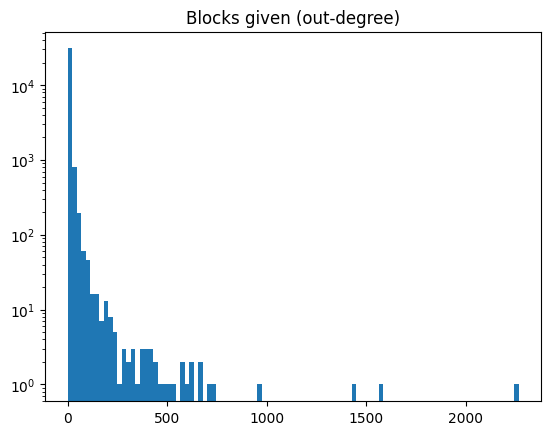

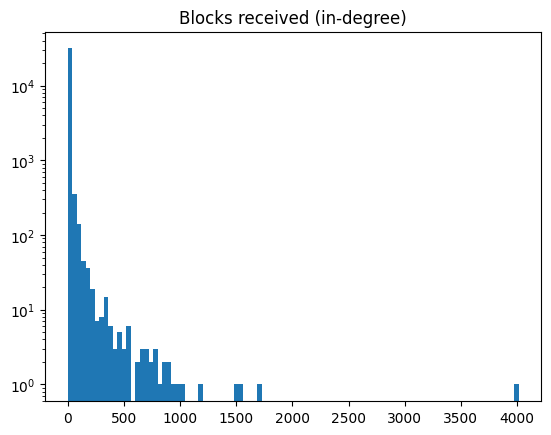

In [25]:
deg_df = pd.DataFrame({
    "out_degree": dict(G.out_degree()).values(),
    "in_degree": dict(G.in_degree()).values()
})

plt.figure()
plt.hist(deg_df["out_degree"], bins=100, log=True)
plt.title("Blocks given (out-degree)")
plt.show()

plt.figure()
plt.hist(deg_df["in_degree"], bins=100, log=True)
plt.title("Blocks received (in-degree)")
plt.show()

In [25]:
corr_cols = [
    "blocks_given",
    "blocks_received",
    "posts_count",
    "replies",
    "followers",
    "following"
]

corr = node_features[corr_cols].corr()
print(corr)


                 blocks_given  blocks_received  posts_count   replies  \
blocks_given         1.000000         0.024899     0.026002  0.026460   
blocks_received      0.024899         1.000000     0.093543  0.085910   
posts_count          0.026002         0.093543     1.000000  0.947653   
replies              0.026460         0.085910     0.947653  1.000000   
followers           -0.002134         0.444730     0.125589  0.112473   
following           -0.002234         0.129555     0.082236  0.073491   

                 followers  following  
blocks_given     -0.002134  -0.002234  
blocks_received   0.444730   0.129555  
posts_count       0.125589   0.082236  
replies           0.112473   0.073491  
followers         1.000000   0.433005  
following         0.433005   1.000000  


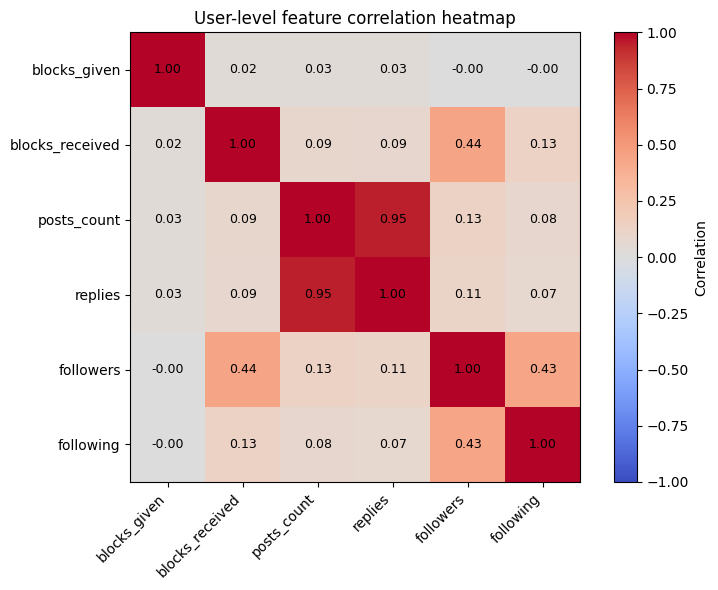

In [26]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)

# annotate values
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=9)

plt.title("User-level feature correlation heatmap")
plt.tight_layout()
plt.show()


In [30]:
feature_cols = [
    "posts_count",
    "replies",
    "followers",
    "following",
    "blocks_received",
    "blocks_given",
    "in_degree",
    "out_degree",
    "pagerank",
    "clustering"
]

X = node_features[feature_cols]
y = node_features["block_bucket"]
